In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [6]:
round((df.isnull().sum()/df.shape[0])*100,2)

,0
PassengerId,0.00
Survived,0.00
Pclass,0.00
Name,0.00
Sex,0.00
Age,19.87
SibSp,0.00
Parch,0.00
Ticket,0.00
Fare,0.00


In [7]:
df.drop("Cabin",axis=1,inplace=True)# permant save

<Axes: ylabel='Age'>

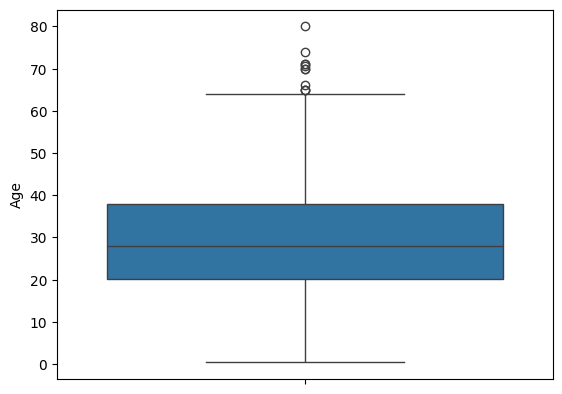

In [8]:
import seaborn as sns
sns.boxplot(df["Age"])

In [9]:
df.Age.fillna(df.Age.median(),inplace=True)

/tmp/ipython-input-1634043521.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.Age.fillna(df.Age.median(),inplace=True)


In [10]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [11]:
df.Embarked.fillna(df.Embarked.mode()[0],inplace=True)

/tmp/ipython-input-2413181878.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.Embarked.fillna(df.Embarked.mode()[0],inplace=True)


In [12]:
round((df.isnull().sum()/891)*100,2)

,0
PassengerId,0.0
Survived,0.0
Pclass,0.0
Name,0.0
Sex,0.0
Age,0.0
SibSp,0.0
Parch,0.0
Ticket,0.0
Fare,0.0


In [13]:
round((df.isnull().sum(axis=1)/891)*100,2) > 7

,0
0,False
1,False
2,False
3,False
4,False
...,...
886,False
887,False
888,False
889,False


In [14]:
df['Embarked'].value_counts()

,count
Embarked,
S,646
C,168
Q,77


# Feature Engineering

In [15]:
df['new'] = df.Age/2 # this is not a feature eng

In [16]:
df.drop("new",axis=1,inplace=True)

In [17]:
df['Family_Size'] = df.Parch+df.SibSp+1

In [18]:
df['senior'] = df.Age.apply(lambda x :1  if x>60 else 0)

In [19]:
df['Gender_age'] = df.apply(lambda x:"child" if x['Age']<15 else x["Sex"],axis=1)

In [20]:
df.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Family_Size,senior,Gender_age
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0,male
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0,female
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,0,female
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0,female
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,0,male
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,Q,1,0,male
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S,1,0,male
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S,5,0,child
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S,3,0,female
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C,2,0,child


In [21]:
df.Gender_age.value_counts()

,count
Gender_age,
male,538
female,275
child,78


In [22]:
df.drop(['PassengerId','Name','SibSp','Parch','Ticket','Sex'],axis=1,inplace=True)

In [23]:
df

,Survived,Pclass,Age,Fare,Embarked,Family_Size,senior,Gender_age
0,0,3,22.0,7.2500,S,2,0,male
1,1,1,38.0,71.2833,C,2,0,female
2,1,3,26.0,7.9250,S,1,0,female
3,1,1,35.0,53.1000,S,2,0,female
4,0,3,35.0,8.0500,S,1,0,male
...,...,...,...,...,...,...,...,...
886,0,2,27.0,13.0000,S,1,0,male
887,1,1,19.0,30.0000,S,1,0,female
888,0,3,28.0,23.4500,S,4,0,female
889,1,1,26.0,30.0000,C,1,0,male


In [24]:
df = pd.get_dummies(df,columns=['Embarked','Gender_age'],drop_first=True)

In [25]:
df

,Survived,Pclass,Age,Fare,Family_Size,senior,Embarked_Q,Embarked_S,Gender_age_female,Gender_age_male
0,0,3,22.0,7.2500,2,0,False,True,False,True
1,1,1,38.0,71.2833,2,0,False,False,True,False
2,1,3,26.0,7.9250,1,0,False,True,True,False
3,1,1,35.0,53.1000,2,0,False,True,True,False
4,0,3,35.0,8.0500,1,0,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,13.0000,1,0,False,True,False,True
887,1,1,19.0,30.0000,1,0,False,True,True,False
888,0,3,28.0,23.4500,4,0,False,True,True,False
889,1,1,26.0,30.0000,1,0,False,False,False,True


In [26]:
from sklearn.model_selection import train_test_split

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (712, 9)
Shape of X_test: (179, 9)
Shape of y_train: (712,)
Shape of y_test: (179,)


In [27]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data (X_train) and transform both X_train and X_test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames for easier inspection (optional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("X_train_scaled head:")
display(X_train_scaled.head())
print("\nX_test_scaled head:")
display(X_test_scaled.head())

X_train_scaled head:


,Pclass,Age,Fare,Family_Size,senior,Embarked_Q,Embarked_S,Gender_age_female,Gender_age_male
331,-1.614136,1.253641,-0.078684,-0.554666,-0.141624,-0.303355,0.592489,-0.655529,0.802709
733,-0.400551,-0.477284,-0.377145,-0.554666,-0.141624,-0.303355,0.592489,-0.655529,0.802709
382,0.813034,0.215086,-0.474867,-0.554666,-0.141624,-0.303355,0.592489,-0.655529,0.802709
704,0.813034,-0.246494,-0.476230,0.040096,-0.141624,-0.303355,0.592489,-0.655529,0.802709
813,0.813034,-1.785093,-0.025249,3.013909,-0.141624,-0.303355,0.592489,-0.655529,-1.245781



X_test_scaled head:


,Pclass,Age,Fare,Family_Size,senior,Embarked_Q,Embarked_S,Gender_age_female,Gender_age_male
709,0.813034,-0.092634,-0.333901,0.634859,-0.141624,-0.303355,-1.687794,-0.655529,0.802709
439,-0.400551,0.138156,-0.425284,-0.554666,-0.141624,-0.303355,0.592489,-0.655529,0.802709
840,0.813034,-0.708074,-0.474867,-0.554666,-0.141624,-0.303355,0.592489,-0.655529,0.802709
720,-0.400551,-1.785093,0.007966,0.040096,-0.141624,-0.303355,0.592489,-0.655529,-1.245781
39,0.813034,-1.169653,-0.411002,0.040096,-0.141624,-0.303355,-1.687794,-0.655529,-1.245781


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42)

# Fit the model on the scaled training data
log_reg_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred = log_reg_model.predict(X_test_scaled)



In [29]:
y_pred

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 1])

In [30]:
(y_pred==y_test).sum() # correct matching

np.int64(145)

In [31]:
y_test.shape

(179,)

In [32]:
(y_pred==y_test).sum() /y_test.shape

array([0.81005587])

In [33]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8100558659217877

In [34]:
y_pred_train = log_reg_model.predict(X_train_scaled)

accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_train

0.8314606741573034

In [ ]:
# We do not need regularizatyion

In [ ]:
log_reg_model.predict_proba(X_test_scaled)

array([[0.9313424 , 0.0686576 ],
       [0.81812847, 0.18187153],
       [0.9077035 , 0.0922965 ],
       [0.17829447, 0.82170553],
       [0.27877447, 0.72122553],
       [0.04952384, 0.95047616],
       [0.28096199, 0.71903801],
       [0.95028353, 0.04971647],
       [0.25370239, 0.74629761],
       [0.10833263, 0.89166737],
       [0.71049816, 0.28950184],
       [0.92850937, 0.07149063],
       [0.63346061, 0.36653939],
       [0.87131743, 0.12868257],
       [0.82535952, 0.17464048],
       [0.07168838, 0.92831162],
       [0.72266568, 0.27733432],
       [0.28090658, 0.71909342],
       [0.80978886, 0.19021114],
       [0.65582824, 0.34417176],
       [0.91152792, 0.08847208],
       [0.64153147, 0.35846853],
       [0.35089573, 0.64910427],
       [0.90732565, 0.09267435],
       [0.91340898, 0.08659102],
       [0.71681655, 0.28318345],
       [0.5388869 , 0.4611131 ],
       [0.81683674, 0.18316326],
       [0.70247074, 0.29752926],
       [0.29969538, 0.70030462],
       [0.

In [35]:
import numpy as np

np.set_printoptions(suppress=True, precision=5)

In [36]:
y_scores = log_reg_model.predict_proba(X_test)[:,1]#[R,C]


In [37]:
y_scores

array([0.00042, 0.00068, 0.00107, 0.79833, 0.01378, 0.99969, 0.00166,
       0.0034 , 0.01004, 0.17162, 0.39512, 0.00003, 0.00297, 0.00026,
       0.0005 , 0.8658 , 0.21784, 0.00168, 0.00194, 0.18164, 0.00058,
       0.01597, 0.00318, 0.00135, 0.00104, 0.03245, 0.00995, 0.00106,
       0.07657, 0.00098, 0.00123, 0.00372, 0.09495, 0.00145, 0.00147,
       0.00079, 0.1671 , 0.00166, 0.28583, 0.00032, 0.98644, 0.00013,
       0.00033, 0.00034, 0.00026, 0.01814, 0.00129, 0.00086, 0.0005 ,
       0.99891, 0.0615 , 0.99607, 0.00008, 1.     , 0.     , 0.99972,
       0.00058, 1.     , 0.01182, 0.00656, 0.00089, 0.10832, 0.04318,
       0.03461, 0.00034, 0.00007, 0.99609, 0.00027, 0.00052, 0.97439,
       0.03157, 1.     , 0.11124, 0.99714, 0.00067, 0.0002 , 0.00114,
       0.91406, 0.0018 , 0.00057, 0.02502, 0.00445, 1.     , 0.00034,
       0.00153, 0.00479, 1.     , 0.97696, 0.00007, 0.00028, 0.06359,
       0.03682, 0.0008 , 0.00034, 0.00032, 0.00031, 0.09253, 0.00003,
       0.00243, 0.00

In [38]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_scores)

In [39]:
thresholds

array([    inf, 1.     , 1.     , 1.     , 0.99965, 0.99915, 0.99902,
       0.99891, 0.99714, 0.99609, 0.99607, 0.98644, 0.66482, 0.39512,
       0.20885, 0.18164, 0.10832, 0.09495, 0.09253, 0.07657, 0.0615 ,
       0.05656, 0.03857, 0.03157, 0.02661, 0.02502, 0.0232 , 0.01814,
       0.01004, 0.00995, 0.00656, 0.00479, 0.00445, 0.00402, 0.00372,
       0.00333, 0.00318, 0.00297, 0.00243, 0.0018 , 0.00167, 0.00167,
       0.00166, 0.0015 , 0.00147, 0.00107, 0.00106, 0.00057, 0.00054,
       0.00044, 0.00042, 0.00035, 0.00034, 0.00033, 0.00033, 0.00032,
       0.00032, 0.00031, 0.00031, 0.00003, 0.00003, 0.     ])

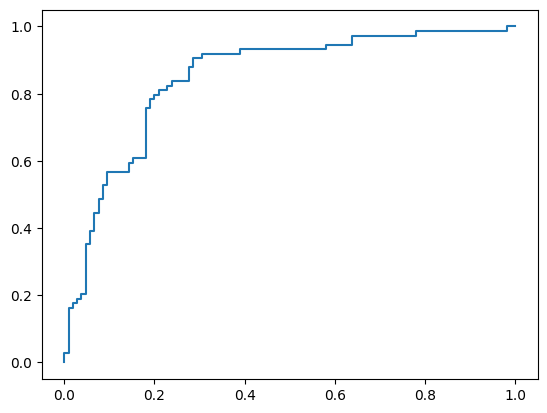

In [41]:
plt.plot(fpr,tpr)

In [42]:
roc_values= pd.DataFrame(list(zip(fpr,tpr,thresholds)),columns=["fpr","tpr","thresholds"])
roc_values

,fpr,tpr,thresholds
0,0.000000,0.000000,inf
1,0.000000,0.013514,1.000000
2,0.000000,0.027027,1.000000
3,0.009524,0.027027,1.000000
4,0.009524,0.162162,0.999652
...,...,...,...
57,0.780952,0.972973,0.000315
58,0.780952,0.986486,0.000313
59,0.980952,0.986486,0.000029
60,0.980952,1.000000,0.000025


In [43]:
tpr - fpr

array([0.     , 0.01351, 0.02703, 0.0175 , 0.15264, 0.14311, 0.15663,
       0.1471 , 0.16062, 0.15109, 0.16461, 0.15508, 0.30373, 0.29421,
       0.33475, 0.32523, 0.37928, 0.36976, 0.4103 , 0.40077, 0.44131,
       0.43179, 0.47233, 0.42471, 0.45174, 0.44221, 0.45573, 0.42716,
       0.5758 , 0.56628, 0.59331, 0.58378, 0.5973 , 0.58777, 0.60129,
       0.58224, 0.59575, 0.58623, 0.59974, 0.56165, 0.60219, 0.59266,
       0.61969, 0.60064, 0.61416, 0.52844, 0.54196, 0.35148, 0.36499,
       0.30785, 0.33488, 0.29678, 0.27773, 0.24916, 0.23012, 0.22059,
       0.20154, 0.19202, 0.20553, 0.00553, 0.01905, 0.     ])

In [44]:
np.argmax(tpr - fpr)

np.int64(42)

In [46]:
thresholds[np.argmax(tpr - fpr)]

np.float64(0.0016571046636518923)

In [47]:
best_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[best_idx]

In [48]:
best_threshold

np.float64(0.0016571046636518923)

In [40]:
import numpy as np

def roc_curve_from_scratch(y_true, y_scores):
    y_true = np.array(y_true)
    y_scores = np.array(y_scores)

    # total positives & negatives
    P = np.sum(y_true == 1)
    N = np.sum(y_true == 0)

    # thresholds: unique scores (desc) + inf
    thresholds = np.sort(np.unique(y_scores))[::-1] #[0.9,0.98,0.78]
    thresholds = np.insert(thresholds, 0, np.inf) #[inf, 0.9,0.98,0.78]

    tpr = []
    fpr = []

    for thresh in thresholds:
        y_pred = (y_scores >= thresh).astype(int) # T -1 F -0

        TP = np.sum((y_pred == 1) & (y_true == 1))
        FP = np.sum((y_pred == 1) & (y_true == 0))
        FN = np.sum((y_pred == 0) & (y_true == 1))
        TN = np.sum((y_pred == 0) & (y_true == 0))

        tpr.append(TP / (TP + FN))
        fpr.append(FP / (FP + TN))

    return np.array(fpr), np.array(tpr), thresholds


In [ ]:
fpr2, tpr2, thresholds2 = roc_curve_from_scratch(y_test, y_scores)

In [ ]:
thresholds2

array([  inf, 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 0.999, 0.999, 0.999, 0.997,
       0.996, 0.996, 0.986, 0.977, 0.977, 0.974, 0.914, 0.911, 0.908,
       0.866, 0.85 , 0.798, 0.692, 0.665, 0.395, 0.286, 0.218, 0.209,
       0.182, 0.172, 0.167, 0.111, 0.108, 0.095, 0.093, 0.093, 0.093,
       0.077, 0.068, 0.064, 0.061, 0.057, 0.043, 0.039, 0.039, 0.037,
       0.035, 0.032, 0.032, 0.032, 0.03 , 0.027, 0.025, 0.023, 0.022,
       0.019, 0.018, 0.018, 0.017, 0.017, 0.016, 0.014, 0.013, 0.012,
       0.012, 0.011, 0.01 , 0.01 , 0.01 , 0.007, 0.007, 0.005, 0.004,
       0.004, 0.004, 0.003, 0.003, 0.003, 0.003, 0.002, 0.002, 0.002,
       0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002,
       0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
       0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
       0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
       0.001, 0.001,

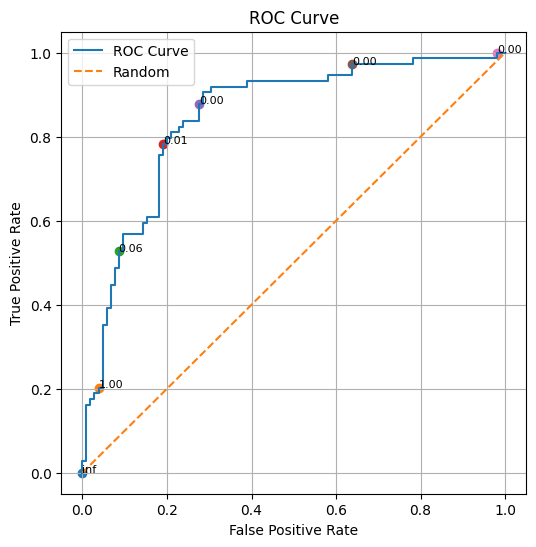

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6, 6))

# ROC curve
plt.plot(fpr, tpr, label="ROC Curve")

# Diagonal (random classifier)
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")

# Mark every 10th threshold
n = 10
for i in range(0, len(thresholds), n):
    plt.scatter(fpr[i], tpr[i])
    plt.text(fpr[i], tpr[i], f"{thresholds[i]:.2f}", fontsize=8)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

plt.show()


In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix
confusion_matrix(y_test,y_pred)

array([[90, 15],
       [19, 55]])

In [ ]:
print("Logistic Regression Confusion Matrix\n")
pd.DataFrame(confusion_matrix(y_test,y_pred),columns=list(range(0,2)))

Logistic Regression Confusion Matrix



,0,1
0,90,15
1,19,55


In [ ]:
auc(fpr,tpr)


NameError: name 'auc' is not defined